# 背景污染诊断 — objaverse.xl 多平台版

- 使用 `objaverse.xl` (v2 API) 获取 github/sketchfab/thingiverse/smithsonian 四个平台的模型
- 每个平台抽 5 个 glb 模型，体素化后分组展示
- 打印每个模型的子 mesh 名称和颜色状态

In [1]:
!pip install objaverse trimesh matplotlib --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.0 MB/s eta 0:00:00


In [2]:
import objaverse.xl as oxl
import numpy as np
import matplotlib.pyplot as plt
import os, shutil, gc, json
from collections import defaultdict
import pandas as pd

SAMPLE_PER_SOURCE = 5
VOXEL_RES = 64
os.makedirs('/content/diag_models', exist_ok=True)
os.makedirs('/content/diag_voxels', exist_ok=True)

print('Loading XL annotations (this downloads parquet files, ~200MB)...')
df = oxl.get_annotations(download_dir='~/.objaverse')
print(f'Total models: {len(df):,}')
print(f'\nSource distribution:')
print(df['source'].value_counts())
print(f'\nFile types:')
print(df['fileType'].value_counts())

2026-06-14 08:00:39.242 | INFO     | objaverse.xl.github:_get_annotations:65 - Downloading https://huggingface.co/datasets/allenai/objaverse-xl/resolve/main/github/github.parquet to ~/.objaverse/github/github.parquet


Loading XL annotations (this downloads parquet files, ~200MB)...


2026-06-14 08:01:21.823 | INFO     | objaverse.xl.thingiverse:get_annotations:46 - Downloading https://huggingface.co/datasets/allenai/objaverse-xl/resolve/main/thingiverse/thingiverse.parquet to ~/.objaverse/thingiverse/thingiverse.parquet
2026-06-14 08:01:33.287 | INFO     | objaverse.xl.smithsonian:get_annotations:47 - Downloading https://huggingface.co/datasets/allenai/objaverse-xl/resolve/main/smithsonian/smithsonian.parquet to ~/.objaverse/smithsonian/smithsonian.parquet
2026-06-14 08:01:33.668 | INFO     | objaverse.xl.sketchfab:_get_annotations:52 - Downloading https://huggingface.co/datasets/allenai/objaverse-xl/resolve/main/sketchfab/sketchfab.parquet to ~/.objaverse/sketchfab/sketchfab.parquet


Total models: 9,767,011

Source distribution:
source
github         5236361
thingiverse    3732212
sketchfab       796031
smithsonian       2407
Name: count, dtype: int64

File types:
fileType
stl      4317074
obj      1620091
fbx      1509719
glb       985124
ply       839343
blend     238201
gltf      127287
dae       123438
usdz        5681
abc         1053
Name: count, dtype: int64


In [3]:
# 每个平台抽 5 个 glb 模型
selected = []
for source in ['sketchfab', 'github', 'thingiverse', 'smithsonian']:
    subset = df[(df['source'] == source) & (df['fileType'] == 'glb')]
    if len(subset) == 0:
        print(f'{source}: 0 glb models, skipping')
        continue
    n = min(SAMPLE_PER_SOURCE, len(subset))
    sampled = subset.sample(n, random_state=42)
    selected.append(sampled)
    print(f'{source:15s}: {len(subset):,} glb models, sampled {n}')

sample_df = pd.concat(selected, ignore_index=True)
print(f'\nTotal to download: {len(sample_df)}')
del df; gc.collect()

sketchfab      : 796,031 glb models, sampled 5
github         : 186,686 glb models, sampled 5
thingiverse: 0 glb models, skipping
smithsonian    : 2,407 glb models, sampled 5

Total to download: 15


30

In [4]:
# 下载模型（glb 文件），并为每个模型保存元数据 JSON
print(f'Downloading {len(sample_df)} models...')
results = oxl.download_objects(objects=sample_df, processes=4)

copied = 0
for fid, local_path in results.items():
    if not (local_path and os.path.exists(local_path)):
        continue
    row = sample_df[sample_df['fileIdentifier'] == fid]
    if len(row) == 0:
        continue
    uid = str(row.iloc[0].get('sha256', fid))[:32]
    source = row.iloc[0]['source']
    dst = os.path.join('/content/diag_models', f'{uid}.glb')
    shutil.copy(local_path, dst)
    with open(os.path.join('/content/diag_models', f'{uid}.json'), 'w') as f:
        json.dump({'source': source, 'fid': fid}, f)
    copied += 1

print(f'Copied {copied} / {len(sample_df)} models')


2026-06-14 08:01:54.378 | INFO     | objaverse.xl.smithsonian:download_objects:312 - Found 0 Smithsonian Objects already downloaded
2026-06-14 08:01:54.379 | INFO     | objaverse.xl.smithsonian:download_objects:315 - Downloading 5 Smithsonian Objects with 4 processes


2026-06-14 08:02:06.005 | INFO     | objaverse.xl.github:download_objects:602 - Provided 5 repoIds with 5 objects to process.
2026-06-14 08:02:06.010 | INFO     | objaverse.xl.github:download_objects:614 - Found 5 repoIds not yet downloaded. Downloading now...
Handling 3D object files: 100%|██████████| 17949/17949 [00:07<00:00, 2253.18it/s]
2026-06-14 08:04:36.389 | INFO     | objaverse.xl.sketchfab:download_objects:508 - Found 0 objects already downloaded
2026-06-14 08:04:36.390 | INFO     | objaverse.xl.sketchfab:download_objects:529 - Downloading 5 new objects across 4 processes
100%|██████████| 5/5 [00:01<00:00,  2.77it/s]


Copied 10 / 15 models


In [11]:
# 体素化 + 颜色采样
# 体素化 + 颜色采样
import trimesh
import json

def parse_model_name(fid):
    if 'sketchfab.com/3d-models/' in fid:
        p = fid.split('/3d-models/')[1].split('-')[:3]
        return 'skfb:' + '-'.join(p)[:35]
    if 'github.com/' in fid:
        return 'gh:' + fid.split('github.com/')[1][-40:]
    if 'thingiverse.com/' in fid:
        return 'tv:' + fid.split('thingiverse.com/')[1][-40:]
    return fid[:45]

import trimesh


def sample_colors(mesh, points, face_idx):
    """4 级降级：贴图 → 纯色 → 顶点色 → 灰色"""
    """4 级降级：贴图 → 纯色 → 顶点色 → 灰色"""
    try:
        if (hasattr(mesh.visual, 'material')
                and hasattr(mesh.visual.material, 'baseColorTexture')
                and mesh.visual.material.baseColorTexture is not None):
            texture = np.array(mesh.visual.material.baseColorTexture)
            uv = mesh.visual.uv
            if uv is not None and len(uv) > 0:
                face_uv = uv[mesh.faces[face_idx]]
                bary = trimesh.triangles.points_to_barycentric(
                    mesh.triangles[face_idx], points)
                sample_uv = (face_uv * bary[:, :, None]).sum(axis=1)
                H, W = texture.shape[:2]
                u, v = sample_uv[:, 0], 1.0 - sample_uv[:, 1]
                px = np.clip((u * (W - 1)).astype(int), 0, W - 1)
                py = np.clip((v * (H - 1)).astype(int), 0, H - 1)
                return texture[py, px][:, :3]
    except Exception:
        pass


    try:
        if (hasattr(mesh.visual, 'material')
                and hasattr(mesh.visual.material, 'baseColorFactor')):
            c = np.array(mesh.visual.material.baseColorFactor[:3]) * 255
            return np.tile(c.astype(np.uint8), (len(points), 1))
    except Exception:
        pass


    try:
        if hasattr(mesh.visual, 'vertex_colors') and mesh.visual.vertex_colors is not None:
            vc = mesh.visual.vertex_colors
            if vc.ndim == 2 and vc.shape[1] >= 3:
                from trimesh.visual.color import vertex_to_face_color
                fc = vertex_to_face_color(vc, mesh.faces)
                return fc[face_idx][:, :3]
    except Exception:
        pass


    return np.tile([128, 128, 128], (len(points), 1))




def voxelize(file_path, resolution=64):
    try:
        scene = trimesh.load(file_path)
        if isinstance(scene, trimesh.Scene):
            mesh = scene.dump(concatenate=True)
        else:
            mesh = scene
        pts, fidx = trimesh.sample.sample_surface(mesh, 200000)
        colors = sample_colors(mesh, pts, fidx)
        mins, maxs = pts.min(axis=0), pts.max(axis=0)
        pts_n = (pts - mins) / (maxs - mins + 1e-8)
        coords = np.clip((pts_n * (resolution - 1)).astype(int), 0, resolution - 1)
        vox = np.zeros((resolution, resolution, resolution, 4), dtype=np.uint8)
        for c, col in zip(coords, colors):
            vox[c[0], c[1], c[2], :3] = col
            vox[c[0], c[1], c[2], 3] = 255
        return vox
    except:
        return None




results = {}
model_dir = '/content/diag_models'
for fname in os.listdir(model_dir):
    if not fname.endswith('.glb'):
        continue
    uid = fname.replace('.glb', '')

    # 读取 per-model 元数据 JSON
    meta_file = os.path.join(model_dir, f'{uid}.json')
    if os.path.exists(meta_file):
        with open(meta_file, 'r') as f:
            info = json.load(f)
        source = info.get('source', 'unknown')
        fid = info.get('fid', uid)
    else:
        source = 'unknown'
        fid = uid
    model_label = parse_model_name(fid)
    fpath = os.path.join(model_dir, fname)



    submesh_names = []
    try:
        scene = trimesh.load(fpath, force='scene')
        if isinstance(scene, trimesh.Scene):
            submesh_names = []
            for i, g in enumerate(scene.geometry.values()):
                name = g.metadata.get('name', f'mesh_{i}') if hasattr(g, 'metadata') else f'mesh_{i}'
                submesh_names.append(name)
            subm_count = len(submesh_names)
        else:
            subm_count = 1
            submesh_names = ['main']
    except:
        subm_count = '?'
        submesh_names = ['?']


    vox = voxelize(fpath, VOXEL_RES)
    if vox is not None:
        has_color = np.any(
            vox[..., :3].sum(axis=-1) != 128 * 3 * (vox[..., 3] > 0)
        )
        results[uid] = {
            'voxel': vox, 'source': source,
            'submesh_count': subm_count, 'submesh_names': submesh_names,
            'model_label': model_label,
            'fid': fid,
            'uid': uid,
        }
        print(f'  [{source:<12s}] {model_label[:45]:<47s} | {subm_count} parts | {"COLOR" if has_color else "GRAY"} | {submesh_names[:3]}')
    else:
        print(f'  [{source:<12s}] {model_label[:45]:<47s} | {subm_count} parts | {"COLOR" if has_color else "GRAY"} | {submesh_names[:3]}')


print(f'\nVoxelized {len(results)} models')

Loaded source mapping: 15 UIDs
  [sketchfab   ] d45e423a0e7c5380   | 2 parts | COLOR | ['mesh_0', 'mesh_1']
  [sketchfab   ] 606b9f3ddd631e70   | 150 parts | COLOR | ['mesh_0', 'mesh_1', 'mesh_2', 'mesh_3']
  [smithsonian ] d2287de504fbb90e   | 1 parts | GRAY | ['mesh_0']
  [smithsonian ] fbbd373b24aaec6b   | 1 parts | GRAY | ['mesh_0']
  [smithsonian ] 1f3478fd4b43deef   | 1 parts | GRAY | ['mesh_0']
  [sketchfab   ] a4623582fcdebce4   | 4 parts | COLOR | ['mesh_0', 'mesh_1', 'mesh_2', 'mesh_3']
  [smithsonian ] f6d5c59e786558bb   | 1 parts | GRAY | ['mesh_0']
  [smithsonian ] a28c70dcd6a3da33   | 1 parts | GRAY | ['mesh_0']
  [sketchfab   ] ebca96cedbcfb970   | 1 parts | COLOR | ['mesh_0']
  [sketchfab   ] cfc57aea97f4e0e5   | 1 parts | COLOR | ['mesh_0']

Voxelized 10 models


DEBUG: 10 models, sources: {'sketchfab': 5, 'smithsonian': 5}



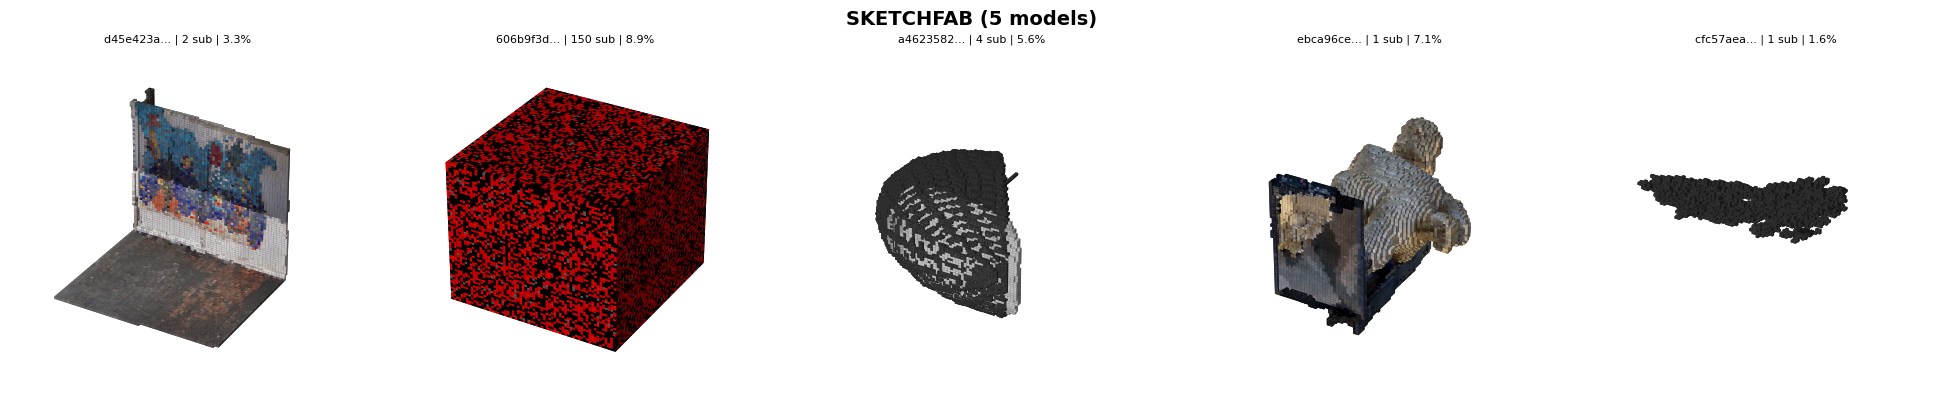

Saved: /content/diag_voxels/sketchfab_samples.png



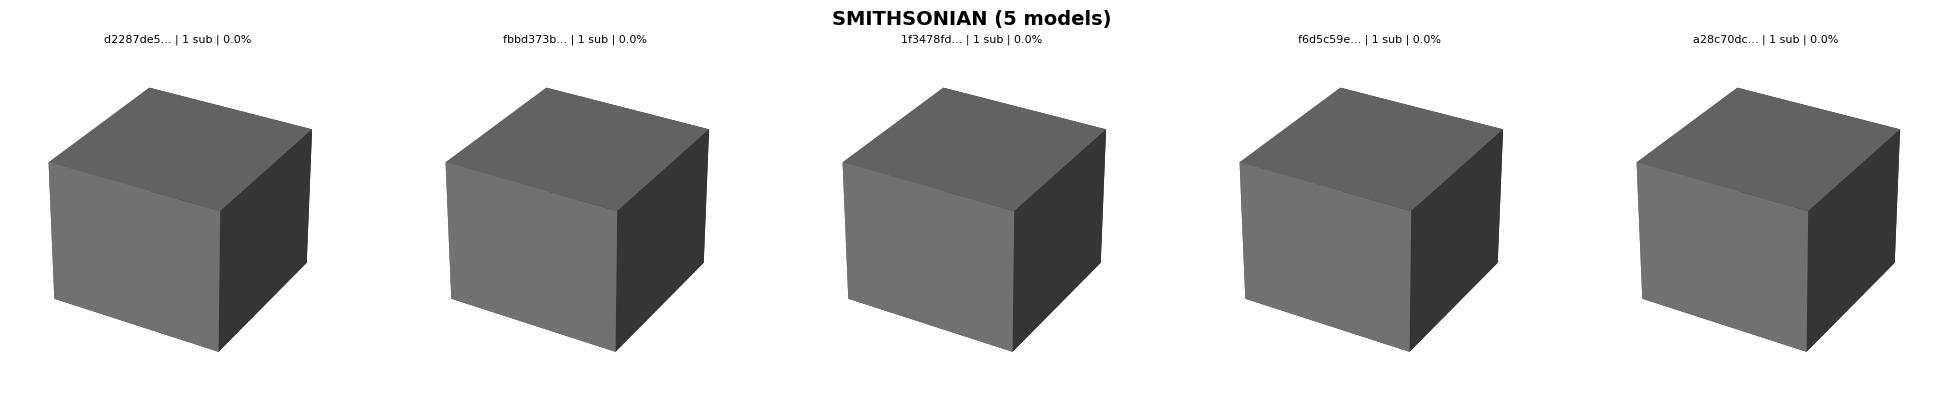

Saved: /content/diag_voxels/smithsonian_samples.png



In [12]:
# 按平台分组可视化
grouped = defaultdict(list)
for uid, info in results.items():
    grouped[info['source']].append(info)

print(f'DEBUG: {len(results)} models, sources: {dict((k, len(v)) for k, v in grouped.items())}\n')

for source in sorted(grouped.keys()):
    items = grouped[source]
    n = len(items)
    cols = min(n, 5)
    rows = max(1, (n + cols - 1) // cols)

    fig = plt.figure(figsize=(4 * cols, 4 * rows))
    fig.suptitle(f'{source.upper()} ({n} models)', fontsize=14, fontweight='bold', y=0.98)

    for i, item in enumerate(items):
        voxel = item['voxel']
        occ = voxel[..., 3] > 0
        colors = voxel[..., :3].astype(float) / 255.0

        try:
            ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
            ax.voxels(occ, facecolors=colors, edgecolor=None)
            fill_pct = occ.mean() * 100
            subm = item['submesh_count']
            lbl = item.get('model_label', item['uid'][:16])
            ax.set_title(f'{lbl} | {subm} sub | {fill_pct:.1f}%', fontsize=7)
            ax.axis('off')
        except Exception as e:
            print(f'  Render error for {item.get("model_label", item["uid"][:16])}: {e}')

    plt.tight_layout()
    path = f'/content/diag_voxels/{source}_samples.png'
    plt.savefig(path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}\n')

In [13]:
# 手动深入检查某个模型的所有子 mesh 材质
# 把 INSPECT_UID 改成你想分析的 uid，重新运行此 cell

INSPECT_UID = 'fbbd373b24aaec6bc2d2e062c3425291'

if INSPECT_UID and any(INSPECT_UID in k for k in results):
    fname = None
    for f in os.listdir('/content/diag_models'):
        if INSPECT_UID in f:
            fname = f
            break

    if fname:
        import trimesh
        scene = trimesh.load(os.path.join('/content/diag_models', fname), force='scene')
        print(f'Model: {fname}')
        print(f'Scene type: {type(scene).__name__}')

        if isinstance(scene, trimesh.Scene):
            for i, (name, geom) in enumerate(scene.geometry.items()):
                print(f'\n--- Submesh {i}: {name} ---')
                print(f'  Vertices: {len(geom.vertices)}, Faces: {len(geom.faces)}')
                print(f'  Visual type: {type(geom.visual).__name__}')

                if hasattr(geom.visual, 'material'):
                    mat = geom.visual.material
                    print(f'  Material type: {type(mat).__name__}')
                    for attr in ['baseColorFactor', 'baseColorTexture', 'metallicFactor', 'roughnessFactor']:
                        if hasattr(mat, attr):
                            val = getattr(mat, attr)
                            if val is not None:
                                val_str = str(val)[:100]
                                print(f'    {attr}: {val_str}')
                else:
                    print(f'  No material')

                if hasattr(geom.visual, 'vertex_colors'):
                    vc = geom.visual.vertex_colors
                    print(f'  vertex_colors: shape={vc.shape if vc is not None else None}')

                if hasattr(geom.visual, 'uv'):
                    uv = geom.visual.uv
                    print(f'  UV: shape={uv.shape if uv is not None else None}')
else:
    print('修改 INSPECT_UID 变量为某个 uid 前缀，重新运行此 cell')
    print(f'Available UIDs: {list(results.keys())[:5]}')

Model: fbbd373b24aaec6bc2d2e062c3425291.glb
Scene type: Scene

--- Submesh 0: GLTF ---
  Vertices: 119802, Faces: 150000
  Visual type: TextureVisuals
  Material type: PBRMaterial
    metallicFactor: 0.100000001490116
    roughnessFactor: 0.800000011920929
  UV: shape=(119802, 2)
